In [ ]:
# 딥러닝 = 입력을 받아 출력을 내는 함수의 일종 (가중치가 그 함수의 파라미터)
# → 이미 좋은 가중치(=이미 잘 맞춰진 함수)가 있다면, 처음부터 다시 만들 필요 없이 불러와 쓰는 게 효율적

# huggingface: 모델(=이미 학습된 함수)을 공유하는 오픈 플랫폼

# 이미지 전처리: 사전학습 모델은 정해진 입력 형식(크기, 채널, 정규화 값)에 맞춰야만 제대로 작동
# → 이게 안 맞으면 모델 자체는 멀쩡해도 성능이 떨어짐

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
100%|██████████| 50/50 [10:18<00:00, 12.37s/it]


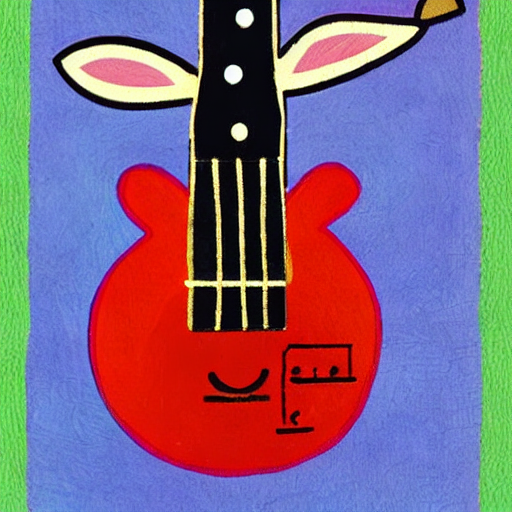

In [2]:
# stable diffusion: 텍스트 입력을 받아 이미지를 생성하는 모델

import torch
import PIL # 이미지처리 라이브러리
from diffusers import StableDiffusionPipeline # 이미지 생성 파이프라인 객체

pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", torch_dtype=torch.float16)

prompt = "a rabbit playing guitar"
images = pipe(prompt).images
images[0]


In [ ]:
# 자연어 데이터는 시퀀스 데이터의 일종
# 자연어 데이터는 모델에 바로 입력할 수 없으므로 전처리가 필요

# 1단계 - 토크나이징: 문장을 단어(토큰) 단위로 쪼개고, 각 토큰을 숫자 ID로 변환
# 2단계 - 임베딩: 그 숫자 ID를 "의미를 담은 벡터"로 변환
#   - 비슷한 문맥의 단어일수록 벡터가 비슷해짐
#   - 학습을 통해 의미가 반영됨 (nn.Embedding = 단어 수 × 차원수 크기의 표, ID로 해당 행을 찾아 씀)

In [ ]:
# 이미지 생성 모델
pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", torch_dtype=torch.float32)

# 텍스트 생성 모델
tokenizer = AutoTokenizer.from_pretrained("microsoft/GODEL-v1_1-large-seq2seq")
model = AutoModelForSeq2SeqLM.from_pretrained("microsoft/GODEL-v1_1-large-seq2seq")

# 텍스트 분류 모델
binary_pipe = pipeline(model="distilbert-base-uncased-finetuned-sst-2-english", device=-1)